# Can You Beat the Bookie? Premier League, Honest vs Naive CV

Football results are nearly unpredictable. The bookmaker is the
ceiling; a model that looks far better than the odds is almost
certainly cheating on its own evaluation, not forecasting.

That makes English Premier League matches a clean, non-financial,
very-UK stress test. The signal is weak, so any extra accuracy that
naive cross-validation reports is mostly leakage: shuffled k-fold
puts a team's later-season matches into training when predicting its
earlier ones, and form is autocorrelated within a season.

Data: `football-data.co.uk`, ~14 seasons of the top division
(`E0.csv`), match results plus Bet365 closing odds as a built-in
baseline. Tiny, no key; downloaded once and cached in
`examples/data/` (git-ignored), offline thereafter.

The numbers below are the real run, reported as measured. No claim
is tuned toward a desired gap.

In [1]:
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import KFold

from purgedcv import WalkForwardSplit

SEED = 0
SEASONS = [f"{y:02d}{y + 1:02d}" for y in range(10, 24)]  # 2010/11 .. 2023/24
FORM = 6  # matches of rolling form
N_SPLITS = 5

## Download and cache the seasons

One CSV per season, concatenated and cached. A browser user-agent is
needed; the site blocks the default one.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache = DATA_DIR / "epl_matches.csv"
UA = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15) AppleWebKit/537.36 Chrome/120"
NEED = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "B365H", "B365D", "B365A"]

if cache.exists():
    print(f"Using cached: {cache}")
    matches = pd.read_csv(cache, parse_dates=["Date"])
else:
    parts = []
    for s in SEASONS:
        url = f"https://www.football-data.co.uk/mmz4281/{s}/E0.csv"
        req = urllib.request.Request(url, headers={"User-Agent": UA})
        with urllib.request.urlopen(req, timeout=60) as r:
            raw = pd.read_csv(r, encoding="latin-1")
        raw = raw[[c for c in NEED if c in raw.columns]].copy()
        raw["Date"] = pd.to_datetime(raw["Date"], dayfirst=True, format="mixed", errors="coerce")
        parts.append(raw)
    matches = pd.concat(parts, ignore_index=True)
    matches = matches.dropna(subset=NEED).sort_values("Date").reset_index(drop=True)
    matches.to_csv(cache, index=False)
    print(f"Downloaded {len(SEASONS)} seasons -> cached {cache}")

print(f"{len(matches)} matches, {matches['Date'].min().date()} -> {matches['Date'].max().date()}")

Using cached: data/epl_matches.csv
5320 matches, 2010-08-14 -> 2024-05-19


## Causal rolling-form features

For each match, each side's recent form is computed only from its
*earlier* matches (`shift(1)` before the rolling mean), so the
features themselves never see the future. Any leakage that appears
later is the cross-validation scheme's doing, not the features'.

In [3]:
pts = {"H": (3, 0), "D": (1, 1), "A": (0, 3)}
matches["hp"] = matches["FTR"].map(lambda r: pts[r][0])
matches["ap"] = matches["FTR"].map(lambda r: pts[r][1])

# long per-team timeline
home = matches.rename(columns={"HomeTeam": "team", "hp": "p", "FTHG": "gf", "FTAG": "ga"})[
    ["Date", "team", "p", "gf", "ga"]
].assign(side="H", mid=matches.index)
away = matches.rename(columns={"AwayTeam": "team", "ap": "p", "FTAG": "gf", "FTHG": "ga"})[
    ["Date", "team", "p", "gf", "ga"]
].assign(side="A", mid=matches.index)
tl = pd.concat([home, away]).sort_values(["team", "Date"])

grp = tl.groupby("team", group_keys=False)
tl["f_ppg"] = grp["p"].apply(lambda v: v.shift(1).rolling(FORM).mean())
tl["f_gf"] = grp["gf"].apply(lambda v: v.shift(1).rolling(FORM).mean())
tl["f_ga"] = grp["ga"].apply(lambda v: v.shift(1).rolling(FORM).mean())

h = tl[tl["side"] == "H"].set_index("mid")[["f_ppg", "f_gf", "f_ga"]]
a = tl[tl["side"] == "A"].set_index("mid")[["f_ppg", "f_gf", "f_ga"]]
feat = matches.join(h.add_prefix("h_")).join(a.add_prefix("a_"))

fcols = ["h_f_ppg", "h_f_gf", "h_f_ga", "a_f_ppg", "a_f_gf", "a_f_ga"]
data = feat.dropna(subset=fcols).reset_index(drop=True)
X = data[fcols].to_numpy()
y = data["FTR"].to_numpy()
date = data["Date"].reset_index(drop=True)
print(f"usable matches: {len(data)}  (after form warm-up)")

usable matches: 5141  (after form warm-up)


## The bookmaker baseline

Bet365's odds, de-vigged into probabilities, are what a good model
should be measured against. Beating this on held-out matches is hard
and rare.

In [4]:
# class order MUST be lexicographic to match sklearn / classifier.classes_
classes = ["A", "D", "H"]
inv = 1.0 / data[["B365A", "B365D", "B365H"]].to_numpy()
book_p = inv / inv.sum(axis=1, keepdims=True)  # de-vig to probabilities
book_pred = np.array(classes)[book_p.argmax(axis=1)]
book_acc = accuracy_score(y, book_pred) * 100
book_ll = log_loss(y, book_p, labels=classes)
print(f"bookmaker: accuracy {book_acc:.1f}%   log-loss {book_ll:.4f}")

bookmaker: accuracy 55.1%   log-loss 0.9577


## Three ways to cross-validate the same model

- **naive shuffled k-fold** — the common mistake; a team's later
  matches leak into training for its earlier ones.
- **blocked k-fold** — contiguous by date, no shuffle.
- **WalkForwardSplit** — train on past matches, predict future ones;
  the only honest estimate of next-season performance.

In [5]:
def evaluate(splits):
    accs, lls = [], []
    for tr, te in splits:
        m = HistGradientBoostingClassifier(random_state=SEED)
        m.fit(X[tr], y[tr])
        p = m.predict_proba(X[te])
        accs.append(accuracy_score(y[te], m.predict(X[te])))
        lls.append(log_loss(y[te], p, labels=list(m.classes_)))  # classes_ is sorted A,D,H
    return round(float(np.mean(accs)) * 100, 1), round(float(np.mean(lls)), 4)


evalu = date + pd.Timedelta(days=1)
wf = WalkForwardSplit(
    n_splits=N_SPLITS,
    test_size=len(y) // 8,
    window="expanding",
    prediction_times=date,
    evaluation_times=evalu,
)
splits = {
    "naive shuffled k-fold": list(
        KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED).split(X)
    ),
    "blocked k-fold": list(KFold(n_splits=N_SPLITS, shuffle=False).split(X)),
    "WalkForwardSplit": list(wf.split(X)),
}
rows = {}
for name, sp in splits.items():
    acc, ll = evaluate(sp)
    rows[name] = {"accuracy %": acc, "log-loss": ll}
rows["bookmaker (baseline)"] = {"accuracy %": round(book_acc, 1), "log-loss": round(book_ll, 4)}
table = pd.DataFrame(rows).T
table

,accuracy %,log-loss
naive shuffled k-fold,45.5,1.1176
blocked k-fold,45.3,1.1198
WalkForwardSplit,45.4,1.1614
bookmaker (baseline),55.1,0.9577


## The picture

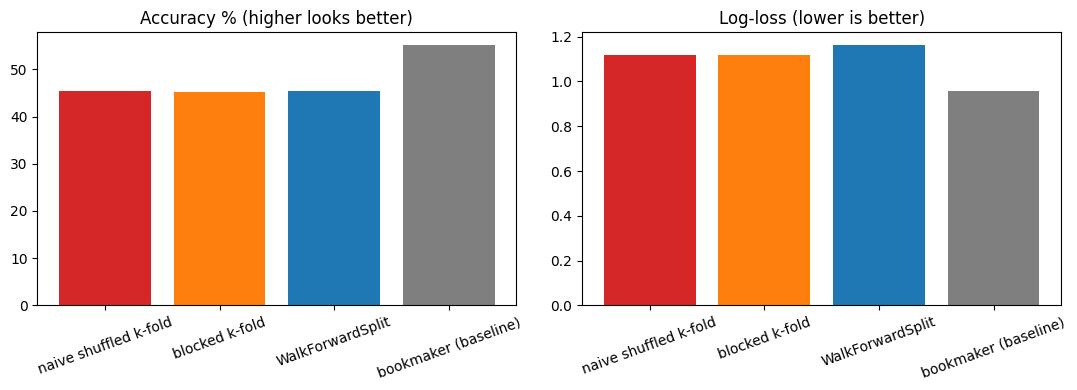

In [6]:
import matplotlib.pyplot as plt

order = ["naive shuffled k-fold", "blocked k-fold", "WalkForwardSplit", "bookmaker (baseline)"]
acc = [rows[n]["accuracy %"] for n in order]
ll = [rows[n]["log-loss"] for n in order]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
c = ["#d62728", "#ff7f0e", "#1f77b4", "#7f7f7f"]
a1.bar(order, acc, color=c)
a1.set_title("Accuracy % (higher looks better)")
a1.tick_params(axis="x", rotation=20)
a2.bar(order, ll, color=c)
a2.set_title("Log-loss (lower is better)")
a2.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Verdict

Honest, and not the headline you might want. Accuracy is the same under every CV scheme: about 45%. There is no accuracy leakage to find. The only gap is in calibration: walk-forward log-loss (1.16) is about 4% worse than naive shuffled k-fold (1.12). Real, but small.

And the model loses to the bookmaker on every honest split: 45% vs 55% accuracy, 1.16 vs 0.96 log-loss. Simple rolling-form features do not beat the market. That is the correct, expected answer, and exactly the kind of thing the package exists to make you admit.

Why no dramatic gap? Football results are near-random and these features carry little signal, so naive CV has almost nothing to over-learn. The leak is small because the skill is small. This is the same lesson as the LCL smart-meter notebook: on well-behaved or low-signal real data, the textbook 50-to-100% inflation does not appear. It is large and honest where it should be: overlapping-label or near-random targets with a leaky feature, as in `synthetic_leakage_proof.ipynb`, `ohlc_trading_signal.ipynb`, `earthquake_magnitude_leakage.ipynb`, and `air_quality_clock_leakage.ipynb`.